# Proyecto 13: Pronósticos y predicciones

La cadena de gimnasios **Model Fitness** está desarrollando una estrategia de interacción con clientes basada en datos analíticos.

Con el fin de combatir la cancelación, Model Fitness ha digitalizado varios de sus perfiles de clientes. Tu tarea consiste en analizarlos y elaborar una estrategia de retención de clientes.

Tienes que:
- Aprender a predecir la probabilidad de pérdida (para el próximo mes) para cada cliente.
- Elaborar retratos de usuarios típicos: selecciona los grupos más destacados y describe sus características principales.
- Analizar los factores que más impactan la pérdida.
- Sacar conclusiones básicas y elaborar recomendaciones para mejorar la atención al cliente:
  - identificar a los grupos objetivo
  - sugerir medidas para reducir la rotación
  - describir cualquier otro patrón que observes con respecto a la interacción con los clientes

## 1. Inicialización y vista previa

In [1]:

# importar librerias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, silhouette_score

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
# leer archivo y vista previa
#df = pd.read_csv('https://code.s3.yandex.net/datasets/gym_churn.csv')  # Ruta en linea
#df = pd.read_csv('/datasets/gym_churn_us.csv')  # Ruta de la plataforma

df = pd.read_csv('../gym_churn_us.csv')
df.info()
print()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


Model Fitness aportó archivos CSV que contienen los datos sobre la cancelación de un mes en concreto e información del mes que lo precedía. 

El dataset incluye los siguientes campos:
- 'Churn' — la cancelación para el mes en cuestión

Campos de dataset actuales:

Datos del usuario del mes anterior
- `gender` - genero del usuario/a
- 'Near_Location' — si el/la usuario/a vive o trabaja en el vecindario donde se encuentra el gimnasio.
- 'Partner' — si el/la usuario/a trabaja en una compañía asociada (el gimnasio tiene empresas asociadas cuyos empleados obtienen descuentos; en esos casos el gimnasio almacena información sobre los empleadores de los clientes).
- Promo_friends — si el/la usuario/a originalmente se inscribió mediante una oferta “trae a un/a amigo/a” (se utilizó el código promocional de un/a amigo/a cuando pagaron el primer abono).
- 'Phone' — si el/la usuario/a aportó el número de teléfono.
- 'Age' - edad
- 'Lifetime' — el tiempo (en meses) desde que el/la usuario/a llegó por primera vez al gimnasio.

Datos del registro de visitas y compras y datos sobre el estado actual de la membresía:  
- 'Contract_period' — 1 mes, 3 meses, 6 meses o 1 año.
- 'Month_to_end_contract' — los meses que faltan hasta que expire el contrato.
- 'Group_visits' — si el/la usuario/a participa en sesiones grupales.
- 'Avg_class_frequency_total' — frecuencia media de visitas por semana a lo largo de la vida del cliente.
- 'Avg_class_frequency_current_month' — frecuencia media de visitas por semana durante el mes en curso.
- 'Avg_additional_charges_total' — cantidad total de dinero gastado en otros servicios del gimnasio: cafetería, productos deportivos, cosméticos, masajes, etc.

In [3]:
print("Valores duplicados: ", df.duplicated().sum())

Valores duplicados:  0


La información muestra que no hay valores ausentes ni duplicados.  
Las columnas son del tipo de dato correcto.

Se continua con el EDA.

## 2. Análisis exploratorio de datos (EDA)

In [4]:
df.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


In [5]:
df.groupby('Churn').mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


In [6]:
# Función para graficar
def graficar(col_name):
    # Crear grafica por cada caracteristica
    for col in df.columns:
        for value in df[col_name].unique():
            sns.histplot(
                data=df[df[col_name] == value],
                x=col,
                label=f'{col_name} = {value}',
                bins=10,
                kde=True
                )
        plt.title(col_name)
        plt.legend()
        plt.show()

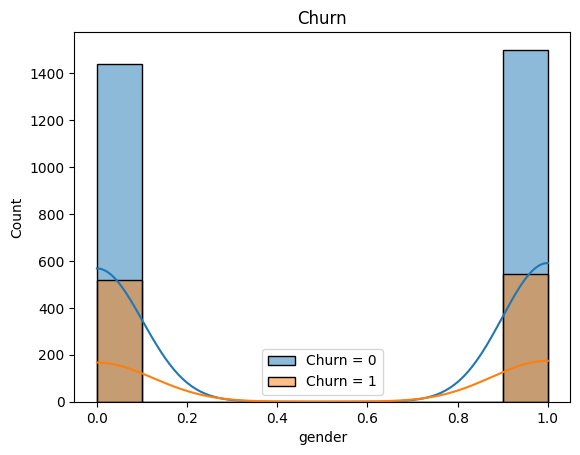

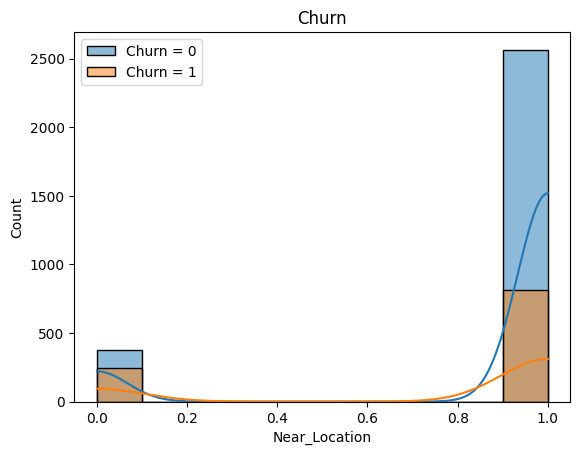

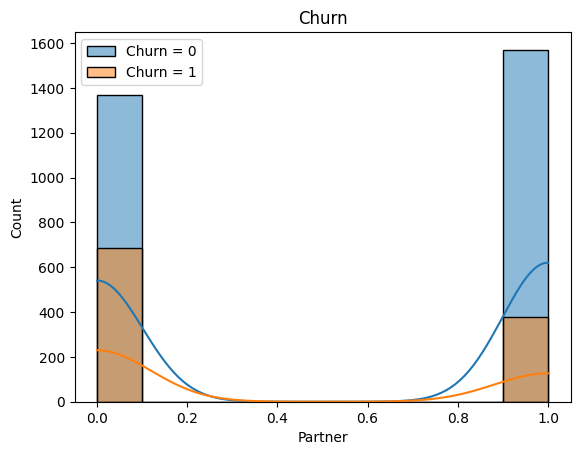

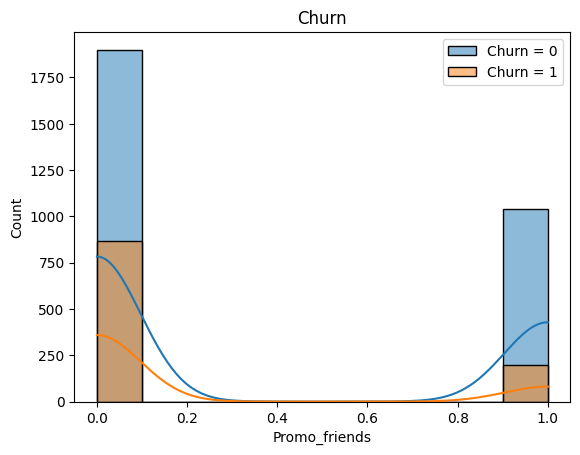

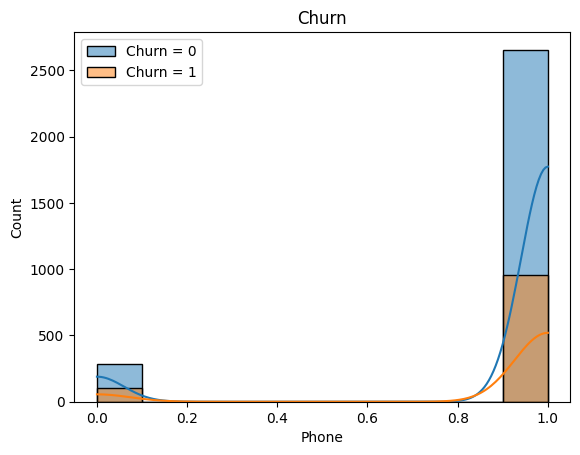

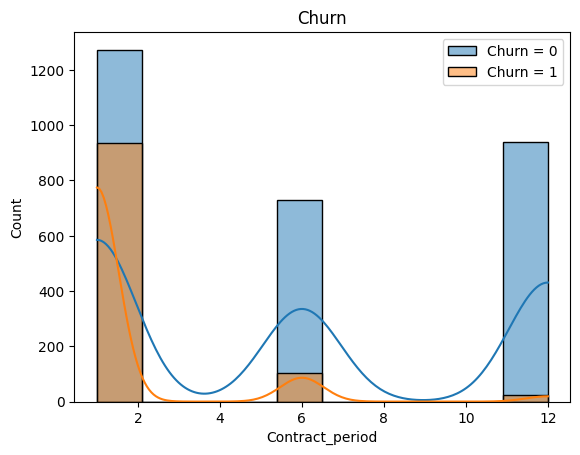

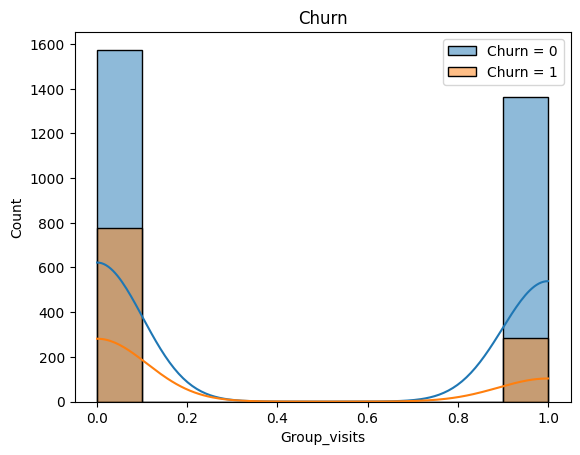

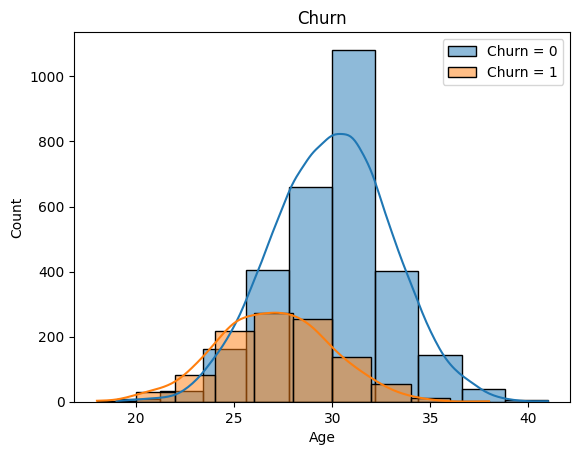

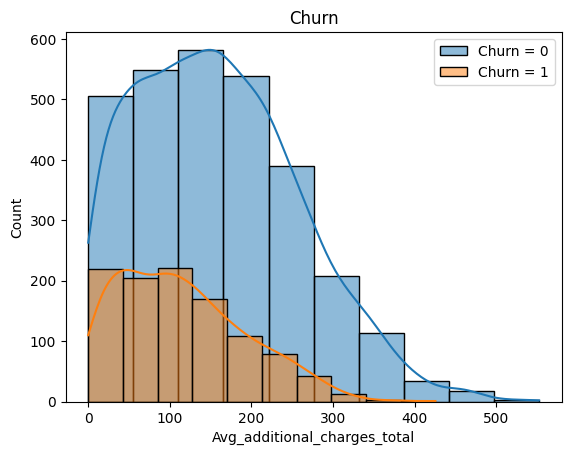

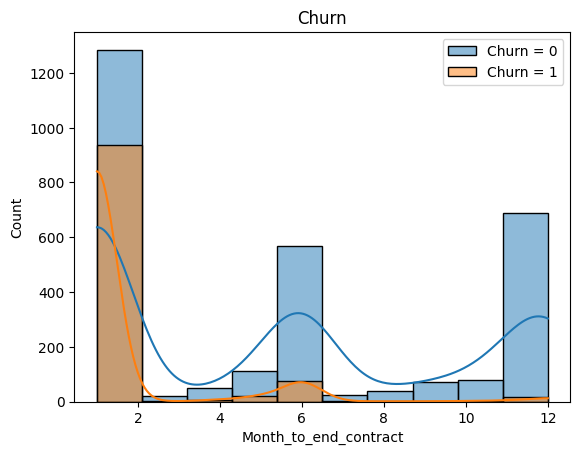

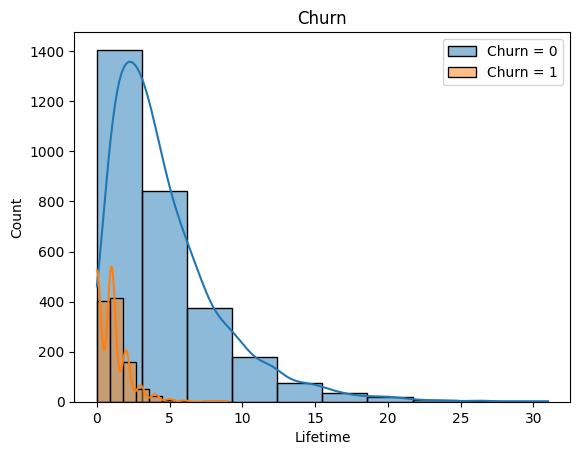

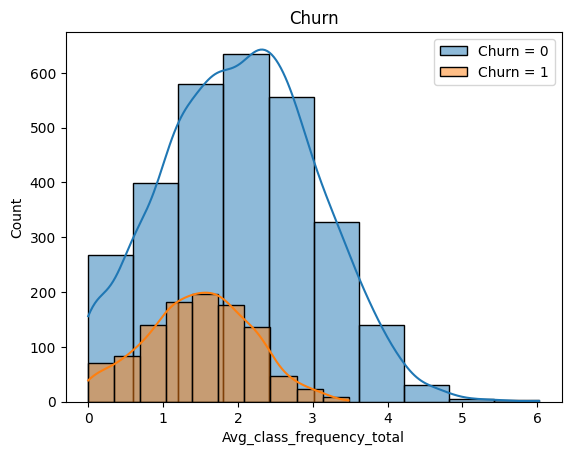

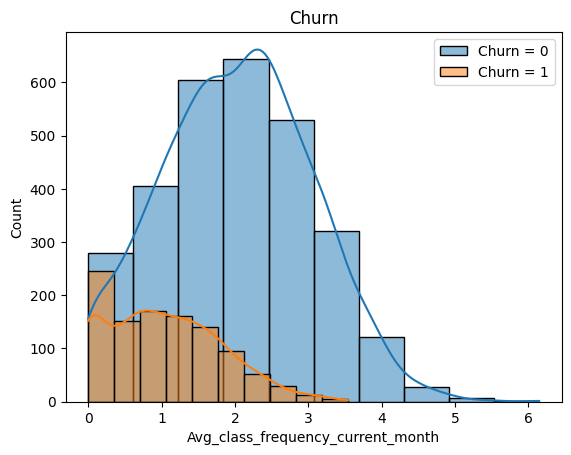

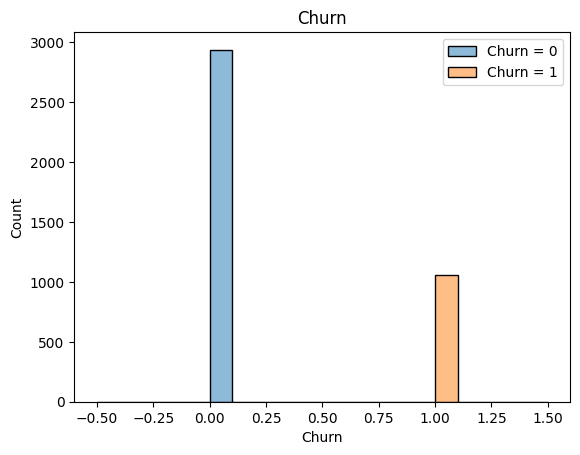

In [7]:
graficar("Churn")

In [8]:
df.corr()["Churn"].sort_values(ascending=False)

Churn                                1.000000
gender                               0.000708
Phone                               -0.001177
Near_Location                       -0.128098
Partner                             -0.157986
Promo_friends                       -0.162233
Group_visits                        -0.175325
Avg_additional_charges_total        -0.198697
Avg_class_frequency_total           -0.249715
Month_to_end_contract               -0.381393
Contract_period                     -0.389984
Age                                 -0.404735
Avg_class_frequency_current_month   -0.412348
Lifetime                            -0.438220
Name: Churn, dtype: float64

En base a la exploración anterior, se observa que
- Las columnas `gender` y `Phone` no estan relacionadas con la columna objetivo
- Las columnas `Age`, `Avg_class_frequency_current_month` y `Lifetime` muestran una alta relación

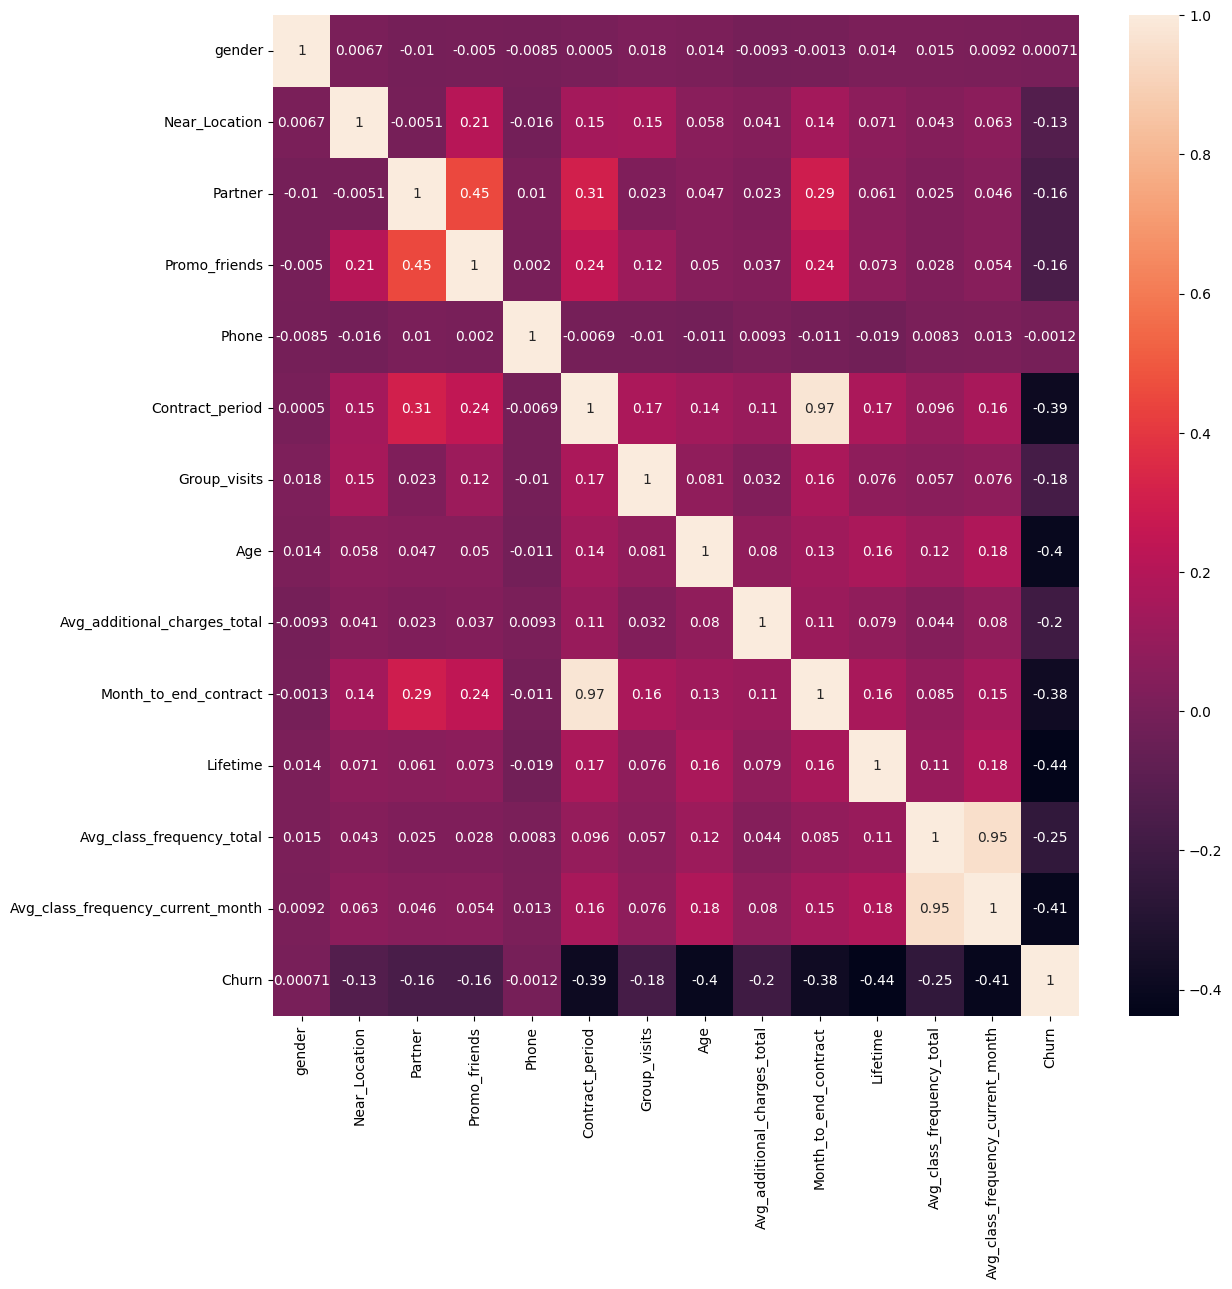

In [9]:
plt.figure(figsize = (13,13))
sns.heatmap(df.corr(), annot = True)
plt.show()

## 3. Modelo para predecir la cancelación de usuarios

In [ ]:
# eliminar columnas que no estan relacionadas con la columna objetivo
df.drop(columns = ["gender", "Phone"], inplace=True)

#comprobar columnas
df.columns

Index(['Near_Location', 'Partner', 'Promo_friends', 'Contract_period',
       'Group_visits', 'Age', 'Avg_additional_charges_total',
       'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total',
       'Avg_class_frequency_current_month', 'Churn'],
      dtype='object')

In [11]:
# Separar los datos en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(df.drop(columns = ['Churn']), df['Churn'], test_size = 0.2, random_state=1234)

In [12]:
X_train.head(3)

,Near_Location,Partner,Promo_friends,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
1623,1,0,0,1,0,30,194.161546,1.0,2,3.070497,3.129331
2229,0,1,0,6,0,28,103.877284,6.0,2,1.704445,1.670306
205,1,1,0,12,1,29,271.303959,11.0,1,1.055493,0.968010


In [13]:
#seleccionar columnas numericas no booleanas, conjunto entrenamiento
numeric_cols = [col for col in X_train.columns if df[col].nunique() > 2]
other_cols = X_train.drop(columns=numeric_cols)

#seleccionar columnas booleanas, conjunto validacion
other_cols_valid = X_val.drop(columns=numeric_cols)
other_cols_valid.head(3)

,Near_Location,Partner,Promo_friends,Group_visits
1760,1,1,1,1
3399,1,1,0,1
979,0,0,0,0


In [14]:
# Escalar datos de entrenamiento
scaler = StandardScaler()

scaled_train = pd.DataFrame( scaler.fit_transform(X_train[numeric_cols]), 
                              columns=numeric_cols,
                              index=X_train.index )

# Unir columnas escaladas con el resto
X_train_scaled = pd.concat([other_cols, scaled_train], axis=1)
X_train_scaled.head(3)

,Near_Location,Partner,Promo_friends,Group_visits,Contract_period,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
1623,1,0,0,0,-0.801120,0.257050,0.473026,-0.783948,-0.439432,1.235956,1.305419
2229,0,1,0,0,0.298375,-0.359562,-0.456713,0.407689,-0.439432,-0.174872,-0.082324
205,1,1,0,1,1.617769,-0.051256,1.267431,1.599326,-0.711579,-0.845094,-0.750309


In [15]:
# Escalar datos de validación
scaled_valid = pd.DataFrame( scaler.transform(X_val[numeric_cols]), 
                              columns=numeric_cols,
                              index=X_val.index )
scaled_valid
# Unir columnas escaladas con el resto
X_valid_scaled = pd.concat([other_cols_valid, scaled_valid], axis=1)
X_valid_scaled.head(3)

,Near_Location,Partner,Promo_friends,Group_visits,Contract_period,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
1760,1,1,1,1,1.617769,-0.667868,-0.923194,1.599326,1.737743,1.318474,1.173982
3399,1,1,0,1,1.617769,0.565356,0.812835,1.837654,-0.167285,0.283295,0.428357
979,0,0,0,0,-0.801120,-0.051256,0.069517,-0.783948,-0.983726,-0.390747,-0.986870


### Modelo: Regresión logística

#### Datos sin escalar

In [16]:
#entrenar modelo
lr_model = LogisticRegression(max_iter=500)
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [17]:
yt_pred_lr  = lr_model.predict(X_train)

acclr_t  = round( accuracy_score(y_train, yt_pred_lr) , 2)
preclr_t = round( precision_score(y_train, yt_pred_lr), 2)
reclr_t  = round( recall_score(y_train, yt_pred_lr)   , 2)

# Conjunto entrenamiento: evaluar exactitud, precisión y recall
print('Accuracy score for logistic regression is:', acclr_t)
print('Precision score for logistic regression is:', preclr_t)
print('Recall score for logistic regression is: ',reclr_t)

Accuracy score for logistic regression is: 0.93
Precision score for logistic regression is: 0.89
Recall score for logistic regression is:  0.84


In [18]:
y_pred_lr  = lr_model.predict(X_val)

acclr_v  = round( accuracy_score(y_val, y_pred_lr) , 2)
preclr_v = round( precision_score(y_val, y_pred_lr), 2)
reclr_v  = round( recall_score(y_val, y_pred_lr)   , 2)


# Conjunto validación: evaluar exactitud, precisión y recall
print('Accuracy score for logistic regression is:', acclr_v)
print('Precision score for logistic regression is:', preclr_v)
print('Recall score for logistic regression is:', reclr_v)

Accuracy score for logistic regression is: 0.94
Precision score for logistic regression is: 0.9
Recall score for logistic regression is: 0.83


#### Datos escalados

In [19]:
#entrenar modelo, datos escalados
lr_model2 = LogisticRegression()
lr_model2.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
yt_pred_lr2  = lr_model2.predict(X_train_scaled)

acclr_t2  = round( accuracy_score(y_train, yt_pred_lr2) , 2)
preclr_t2 = round( precision_score(y_train, yt_pred_lr2), 2)
reclr_t2  = round( recall_score(y_train, yt_pred_lr2)   , 2)

# Conjunto entrenamiento: evaluar exactitud, precisión y recall
print('Accuracy score for logistic regression is:', acclr_t2)
print('Precision score for logistic regression is:', preclr_t2)
print('Recall score for logistic regression is: ',reclr_t2)

Accuracy score for logistic regression is: 0.93
Precision score for logistic regression is: 0.89
Recall score for logistic regression is:  0.84


In [21]:
y_pred_lr2  = lr_model2.predict(X_valid_scaled)

# Conjunto validación: evaluar exactitud, precisión y recall
acclr_v2  = round( accuracy_score(y_val, y_pred_lr2) , 2)
preclr_v2 = round( precision_score(y_val, y_pred_lr2), 2)
reclr_v2  = round( recall_score(y_val, y_pred_lr2)   , 2)

print('Accuracy score for logistic regression is:', acclr_v2)
print('Precision score for logistic regression is:', preclr_v2)
print('Recall score for logistic regression is:', reclr_v2)

Accuracy score for logistic regression is: 0.94
Precision score for logistic regression is: 0.9
Recall score for logistic regression is: 0.83


### Modelo: Bosque aleatorio

In [22]:
rf_model = RandomForestClassifier(n_estimators=5)
rf_model.fit(X_train, y_train)

,n_estimators,5
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
yt_pred_rf  = rf_model.predict(X_train)

accrf_t  = round( accuracy_score(y_train, yt_pred_rf) , 2)
precrf_t = round( precision_score(y_train, yt_pred_rf), 2)
recrf_t  = round( recall_score(y_train, yt_pred_rf)   , 2)

# Conjunto entrenamiento: evaluar exactitud, precisión y recall
print('Accuracy score for random forest is:', accrf_t)
print('Precision score for random forest is:', precrf_t)
print('Recall score for random forest is:', recrf_t)

Accuracy score for random forest is: 0.99
Precision score for random forest is: 0.98
Recall score for random forest is: 0.98


In [24]:
y_pred_rf = rf_model.predict(X_val)

# Conjunto validación: evaluar exactitud, precisión y recall
accrf_v  = round( accuracy_score(y_val, y_pred_rf) , 2)
precrf_v = round( precision_score(y_val, y_pred_rf), 2)
recrf_v = round( recall_score(y_val, y_pred_rf)   , 2)

print('Accuracy score for random forest is:', accrf_v)
print('Precision score for random forest is:', precrf_v)
print('Recall score for random forest is:',  recrf_v)

Accuracy score for random forest is: 0.92
Precision score for random forest is: 0.83
Recall score for random forest is: 0.82


In [25]:
results = pd.DataFrame({
    'Model':           ['Logistic Regression Unscaled', 'Logistic Regression Scaled', 'Random Forest Classifier'],
    'Train Accuracy':  [acclr_t,  acclr_t2,  accrf_t],
    'Train Precision': [preclr_t, preclr_t2, precrf_t],
    'Train Recall ':   [reclr_t,  reclr_t2,  recrf_t],
    'Valid Accuracy':  [acclr_v,  acclr_v2,  accrf_v],
    'Valid Precision': [preclr_v, preclr_v2, precrf_v],
    'Valid Recall ':   [reclr_v,  reclr_v2,  recrf_v]
})
results

,Model,Train Accuracy,Train Precision,Train Recall,Valid Accuracy,Valid Precision,Valid Recall
0,Logistic Regression Unscaled,0.93,0.89,0.84,0.94,0.90,0.83
1,Logistic Regression Scaled,0.93,0.89,0.84,0.94,0.90,0.83
2,Random Forest Classifier,0.99,0.98,0.98,0.92,0.83,0.82


El modelo de **regresión logística** con datos escalados y sin escalar dio los mismos resultados.  
El modelo **bosque de clasificación** muestra sobreajuste en los datos de entrenamiento.  

Se determina que el modelo de **regresión logística** da mejores resultados. 

## 4. Crear clústeres de usuarios/as

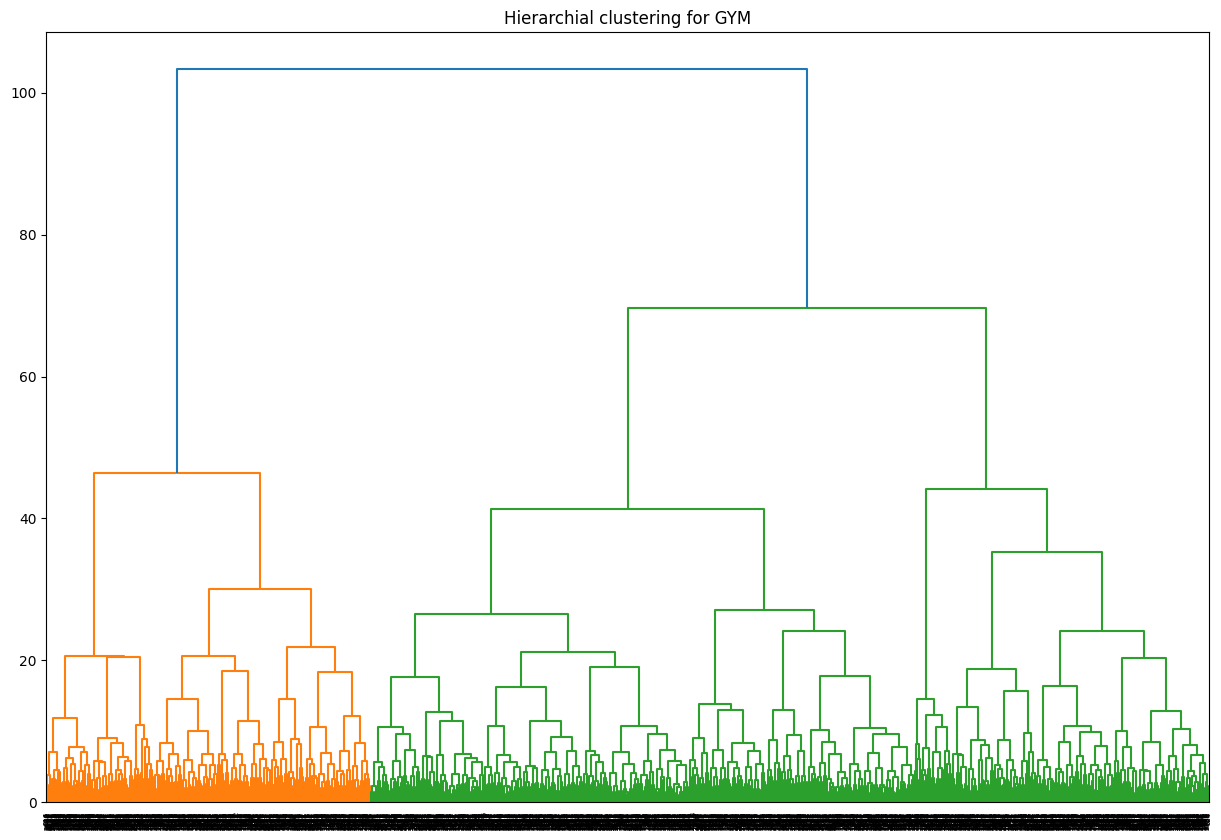

In [26]:
#graficar dendograma
linked = linkage(X_train_scaled, method = 'ward')

plt.figure(figsize=(15, 10))  
dendrogram(linked,
            orientation='top')
plt.title('Hierarchial clustering for GYM')
plt.show()

Silhouette_score 2 Clusters: 0.578

cluster_km
0    2400
1    1600
Name: Churn, dtype: int64



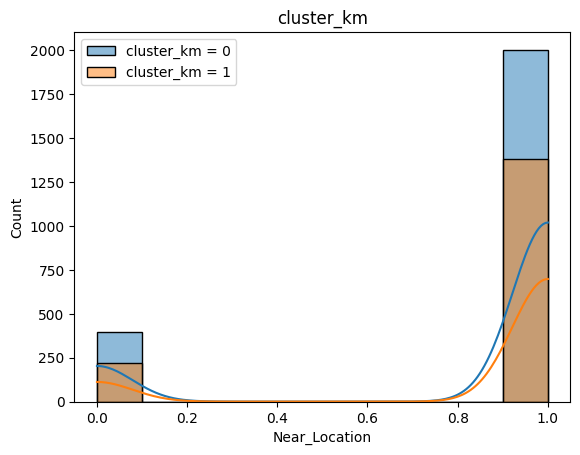

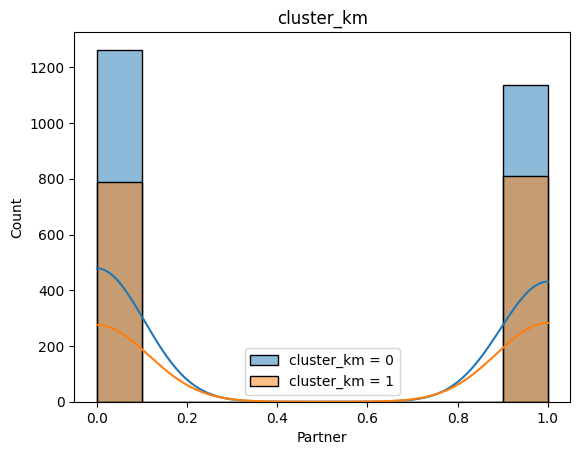

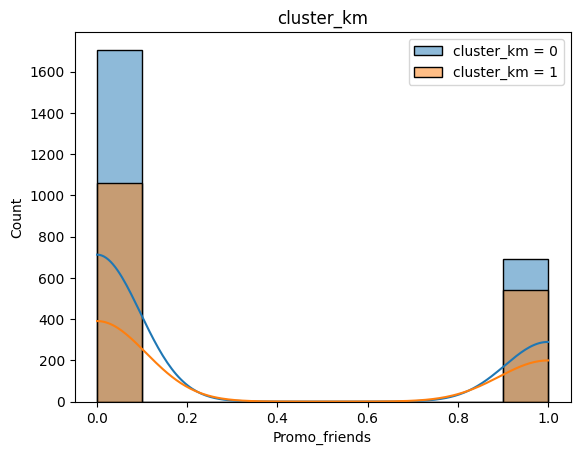

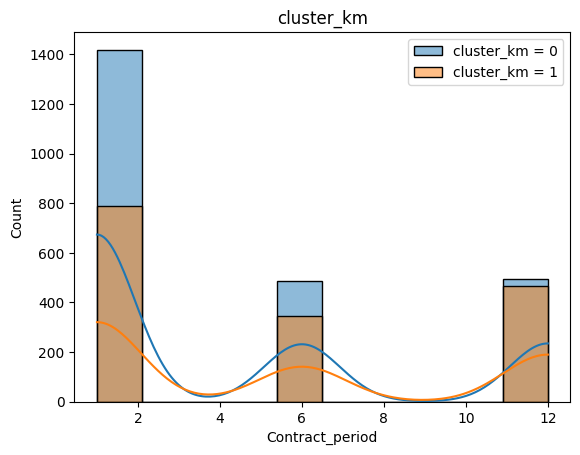

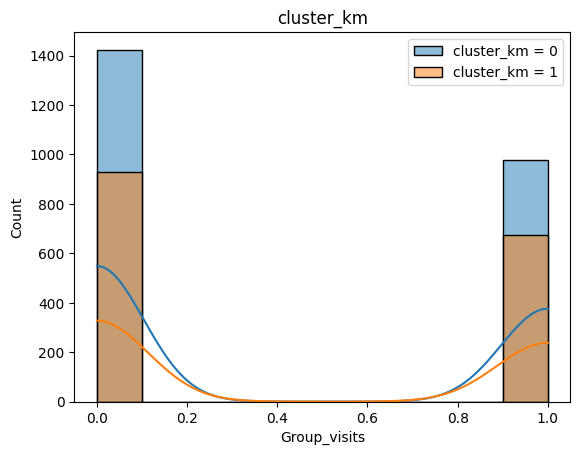

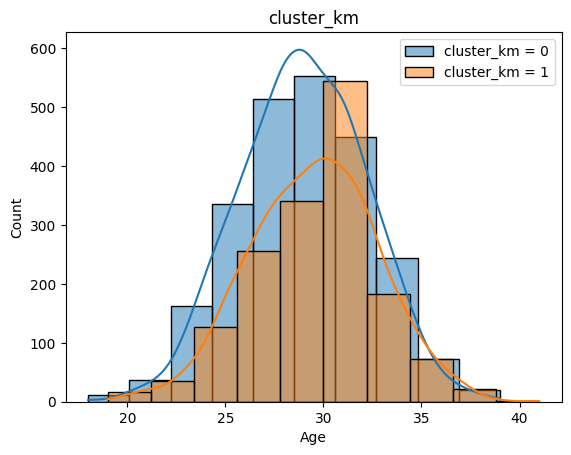

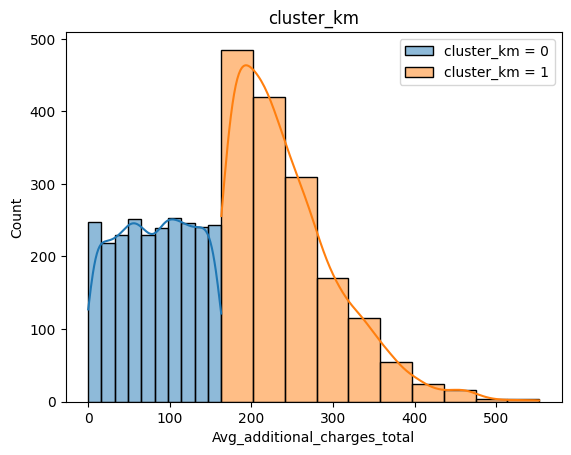

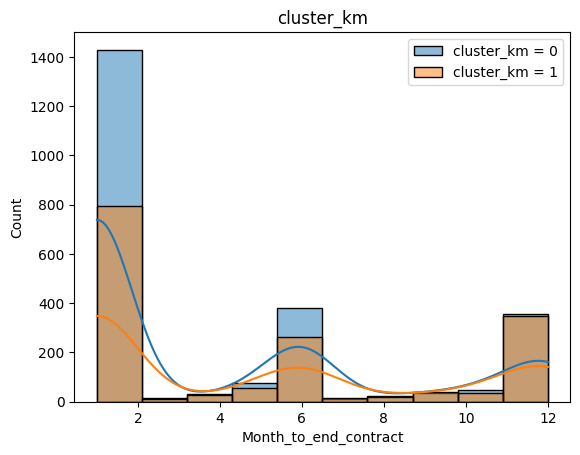

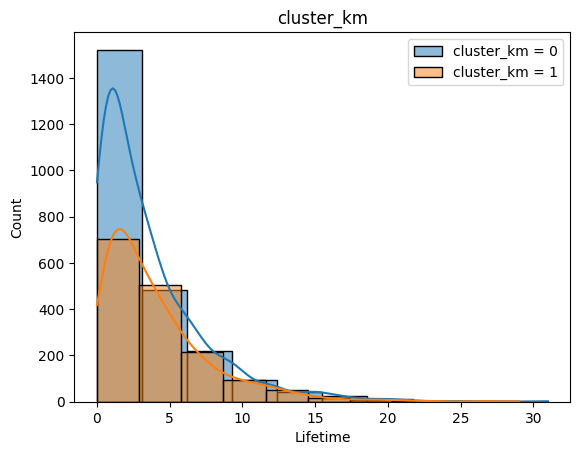

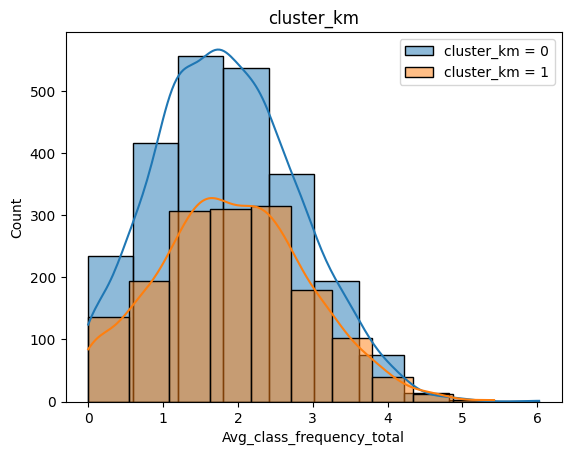

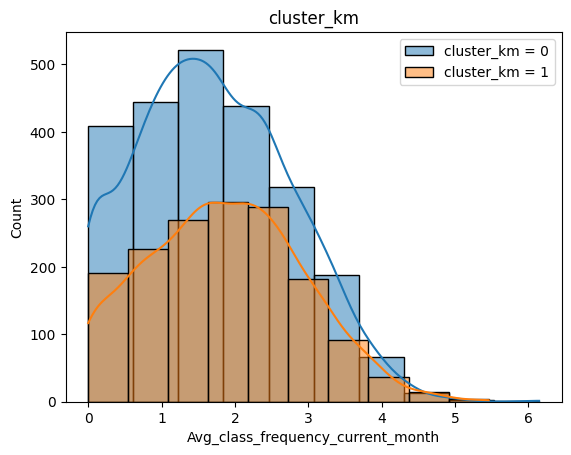

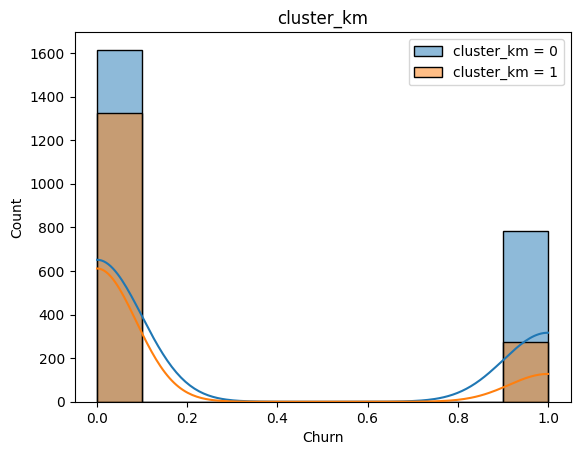

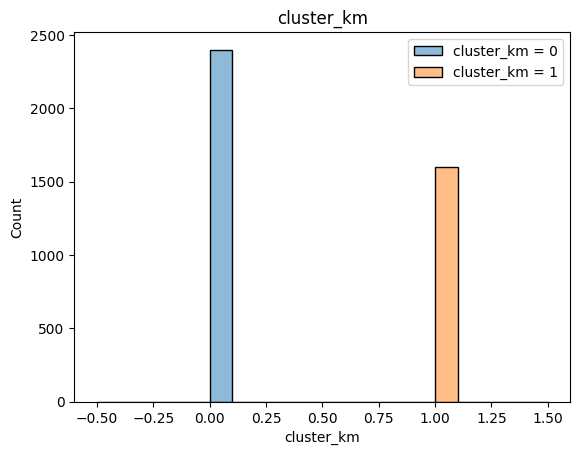

Silhouette_score 3 Clusters: 0.539

cluster_km
0    1588
1     751
2    1661
Name: Churn, dtype: int64



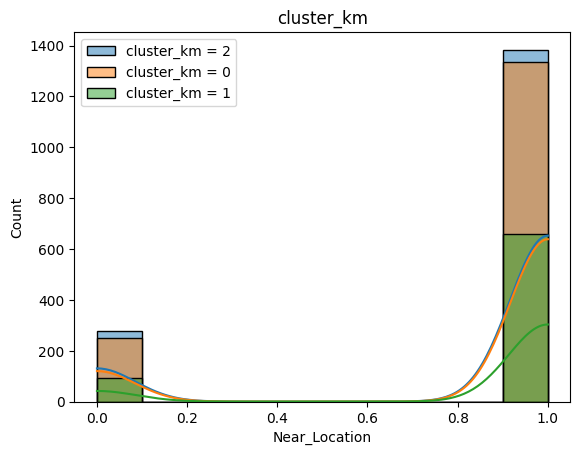

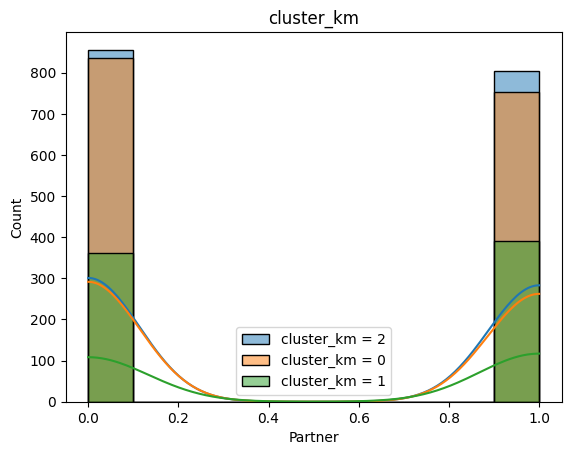

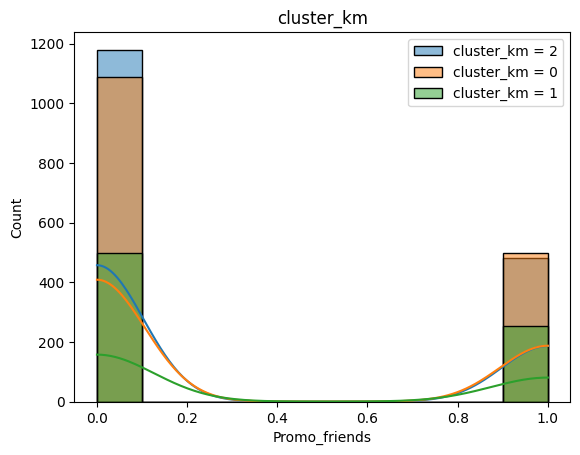

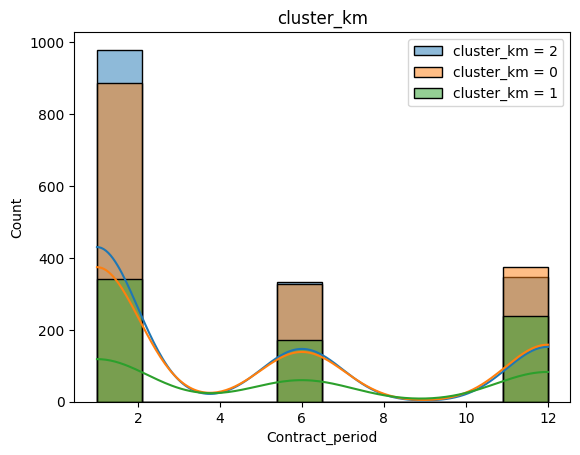

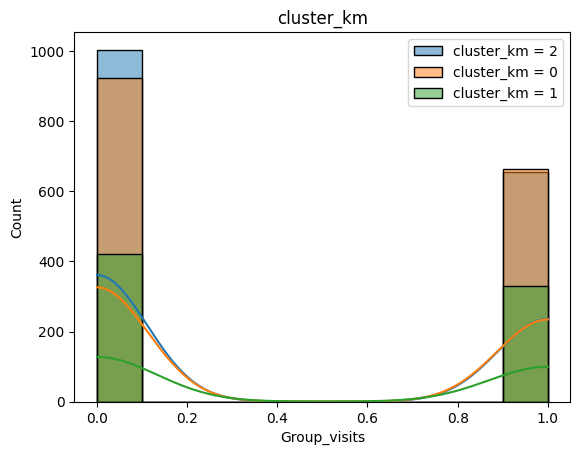

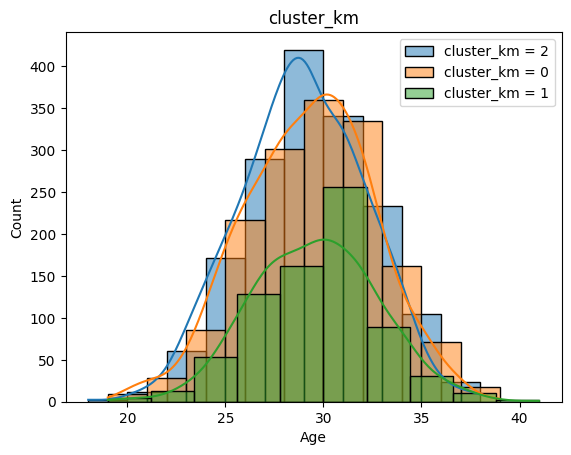

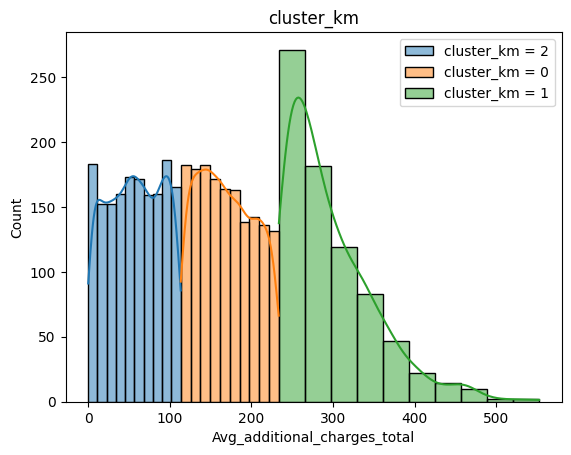

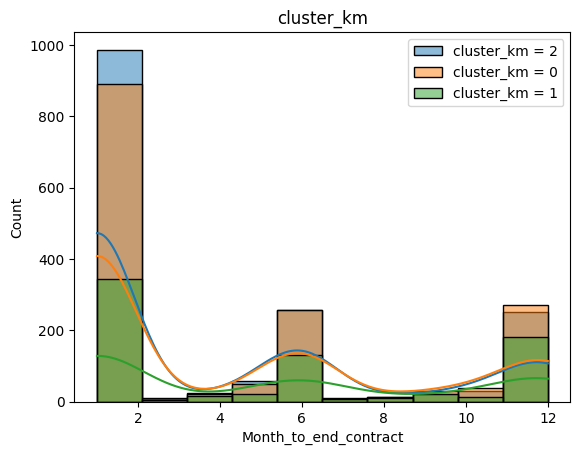

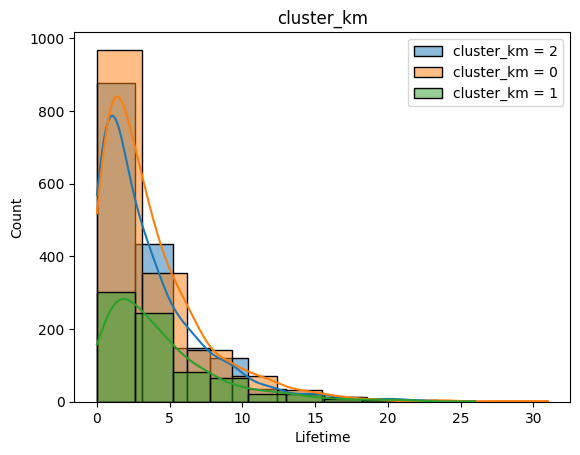

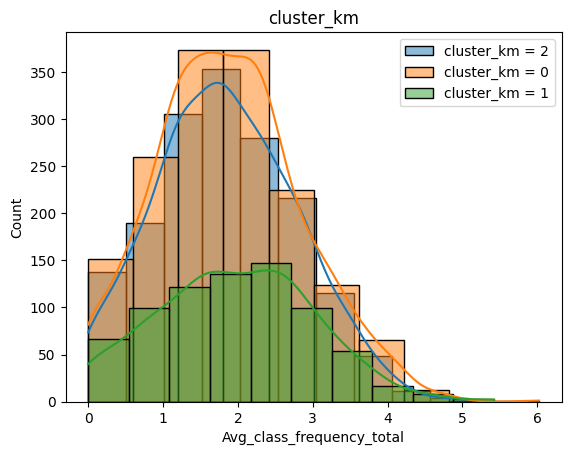

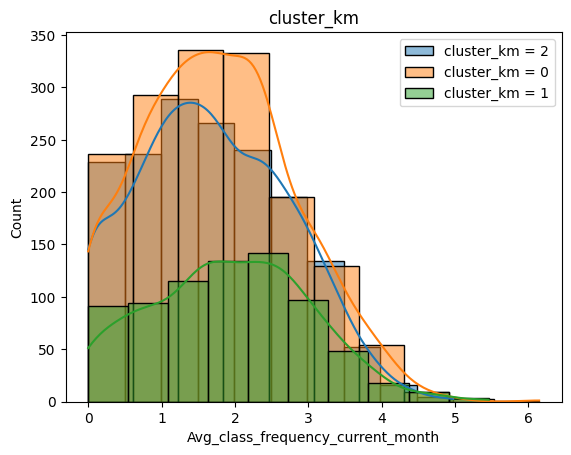

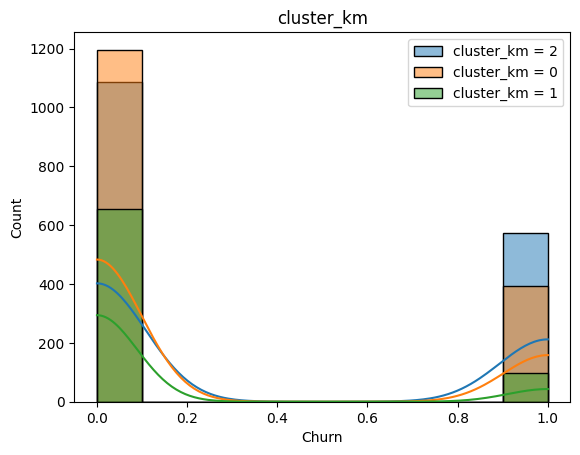

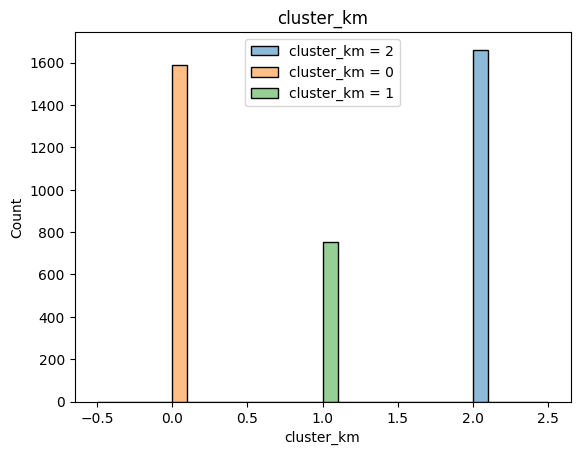

Silhouette_score 4 Clusters: 0.523

cluster_km
0    1322
1    1047
2    1227
3     404
Name: Churn, dtype: int64



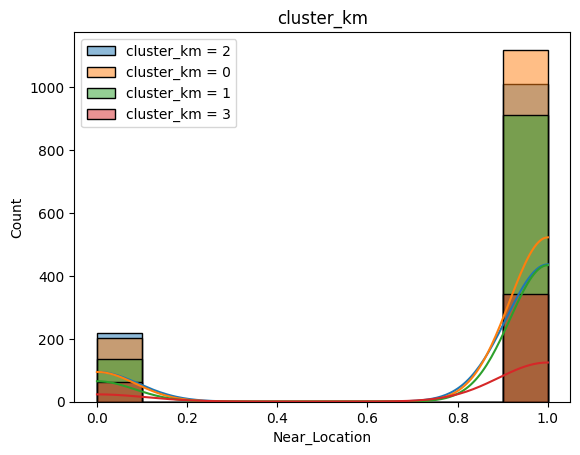

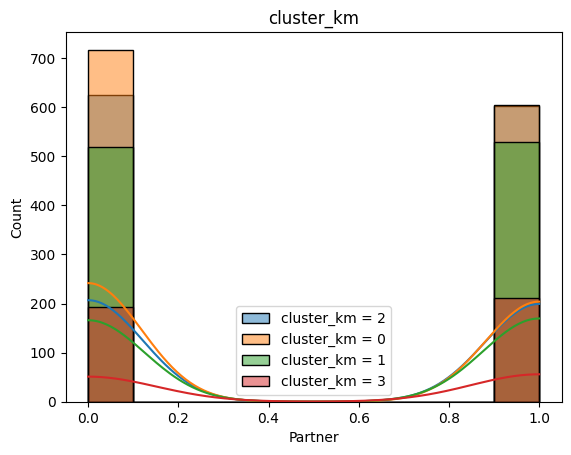

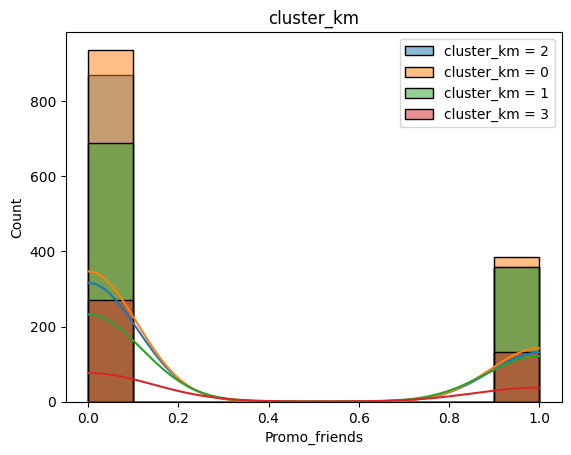

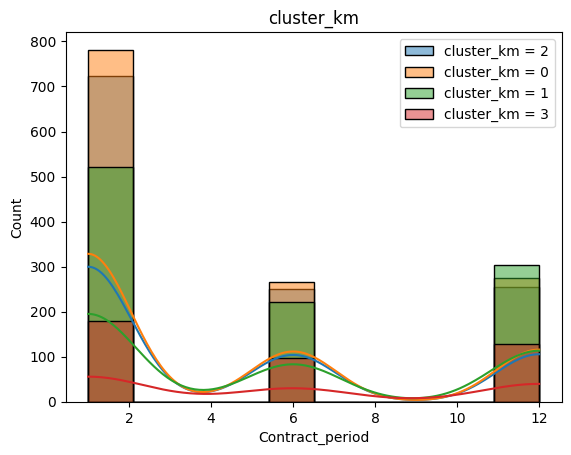

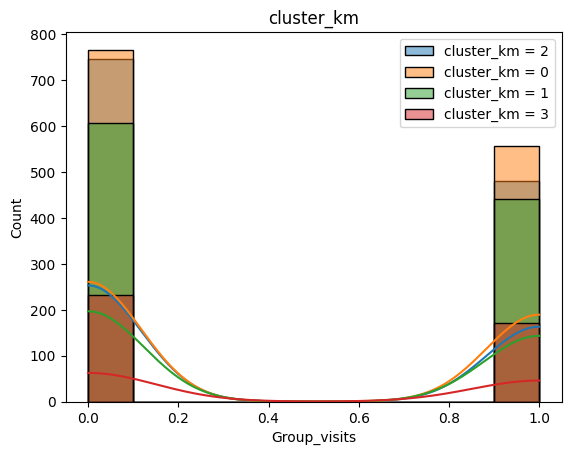

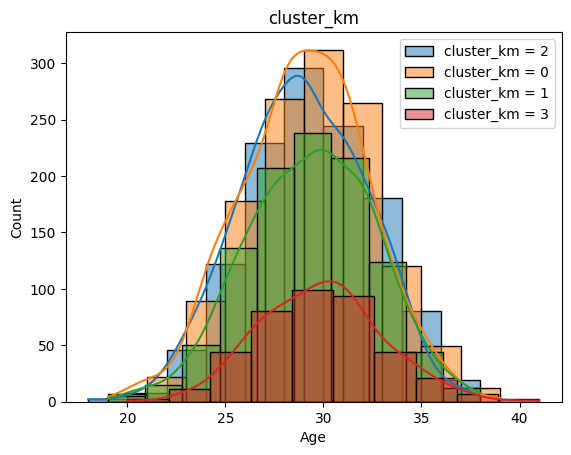

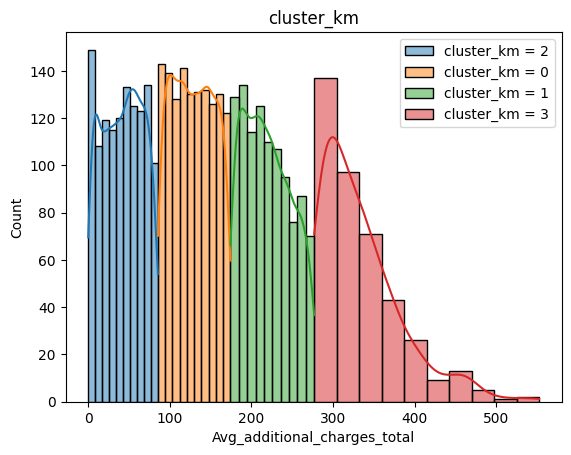

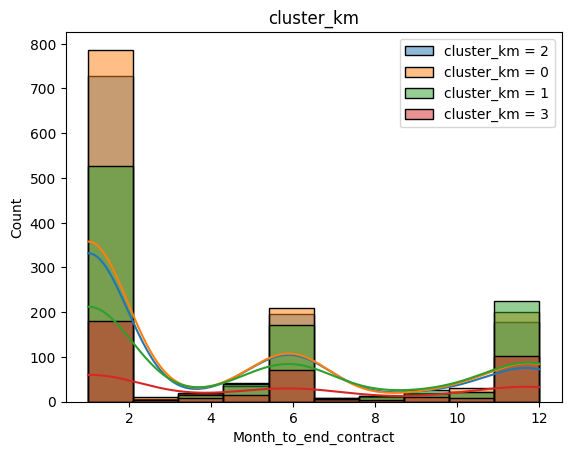

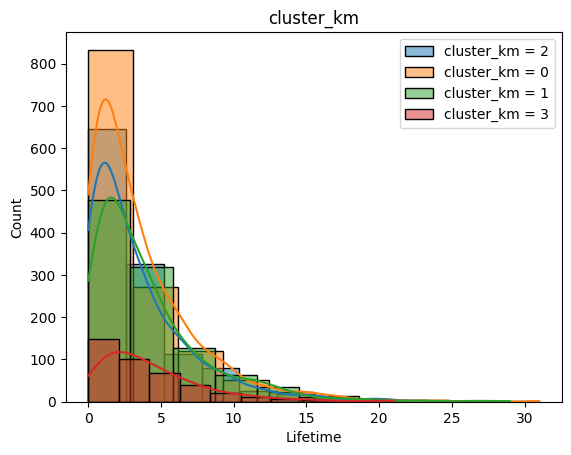

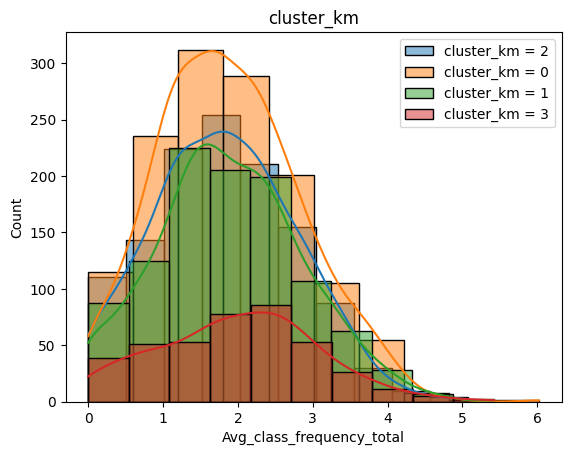

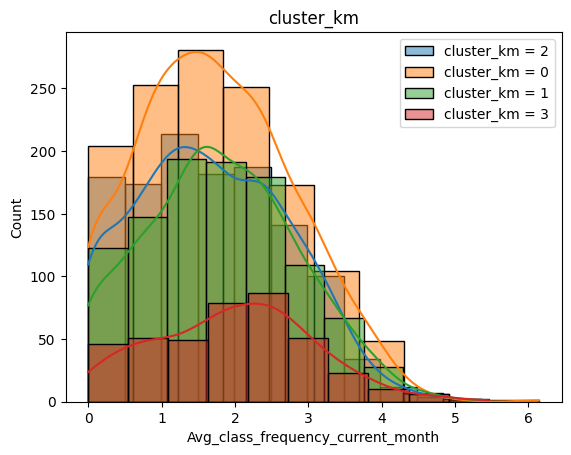

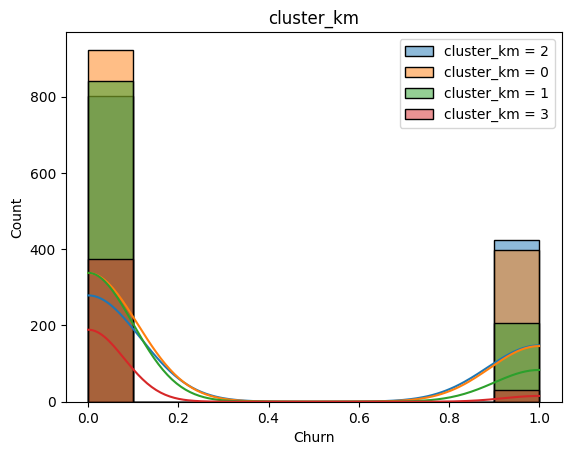

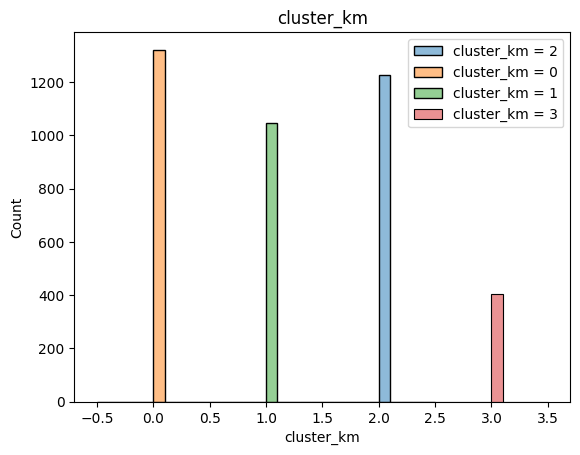

Silhouette_score 5 Clusters: 0.504

cluster_km
0    1066
1     672
2    1082
3     951
4     229
Name: Churn, dtype: int64



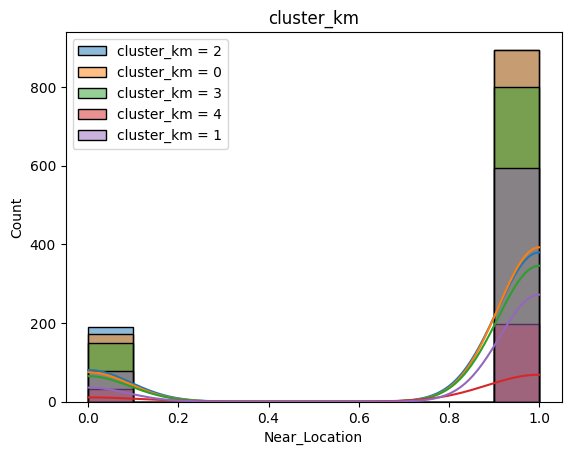

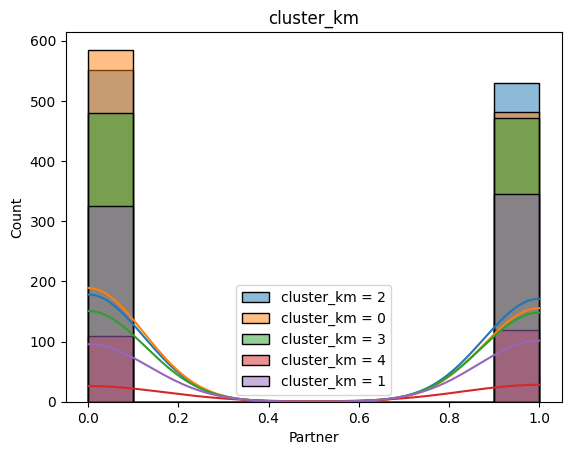

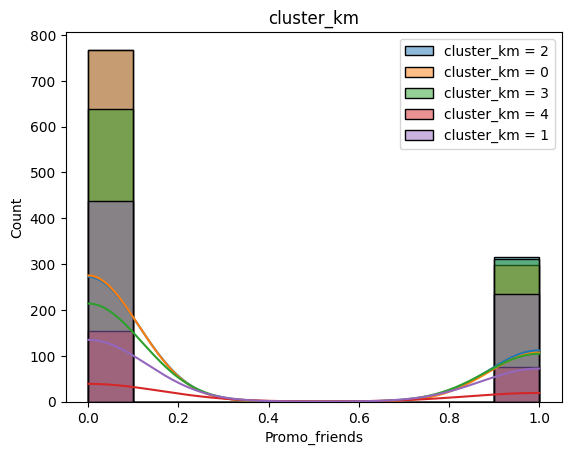

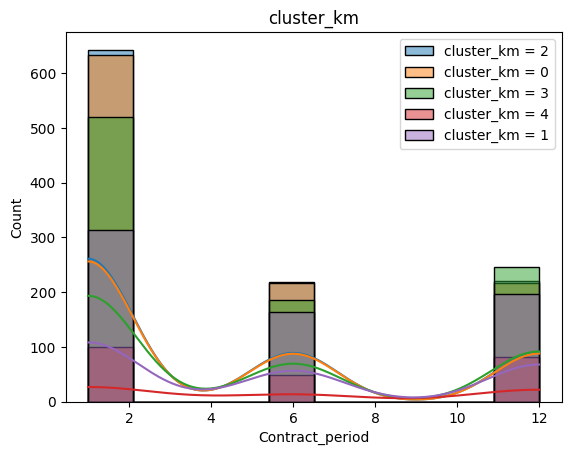

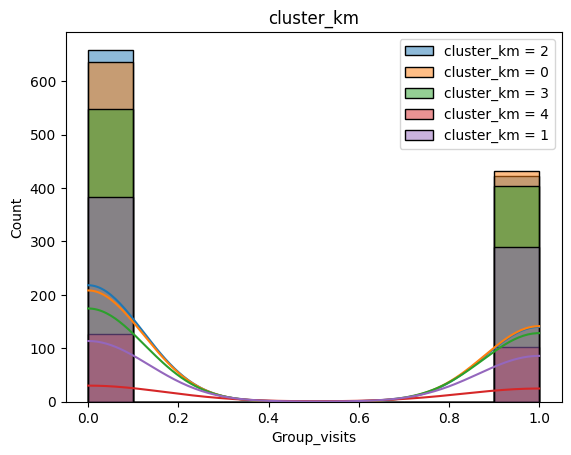

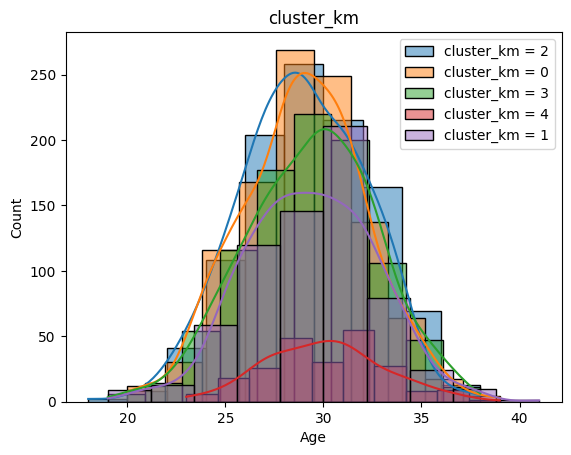

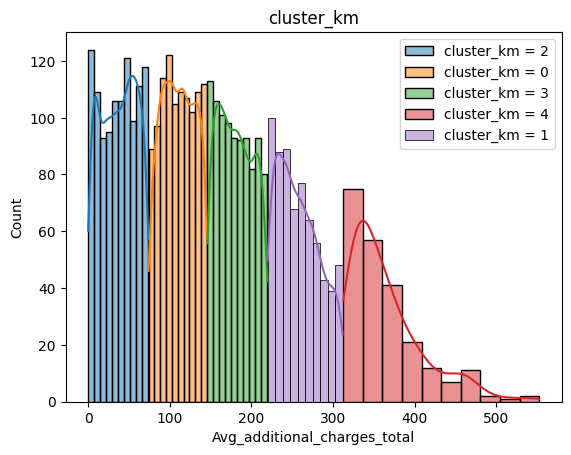

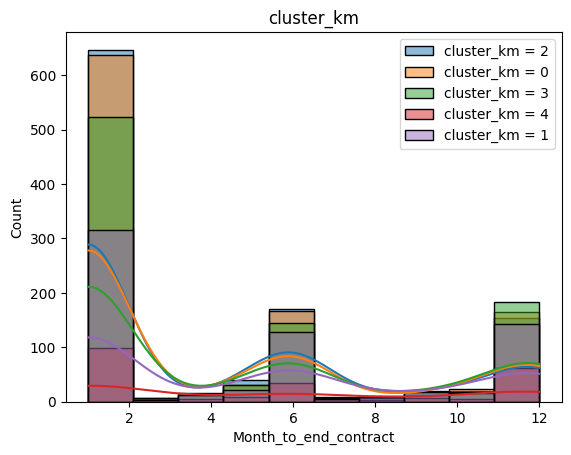

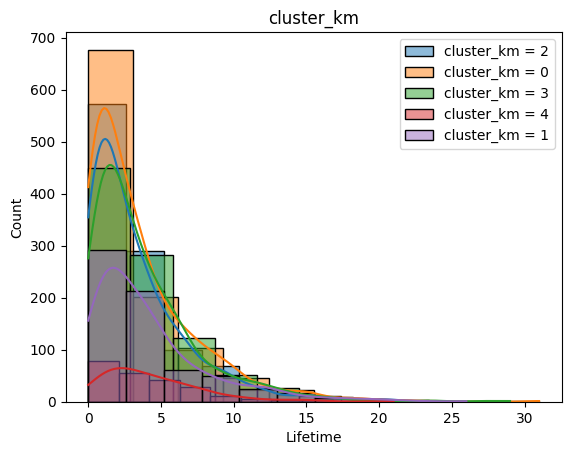

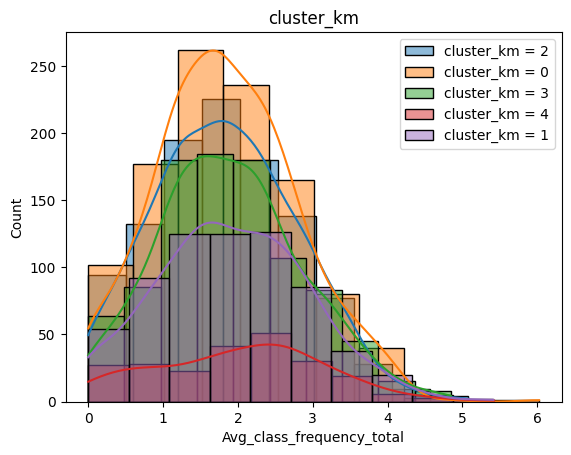

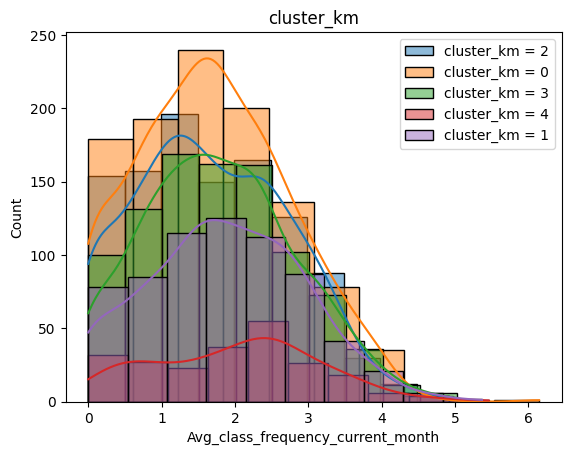

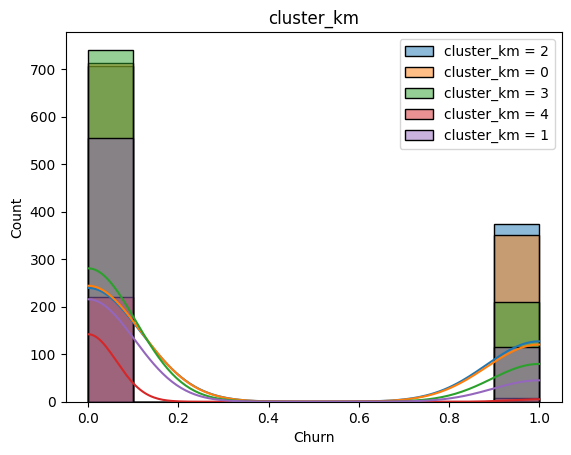

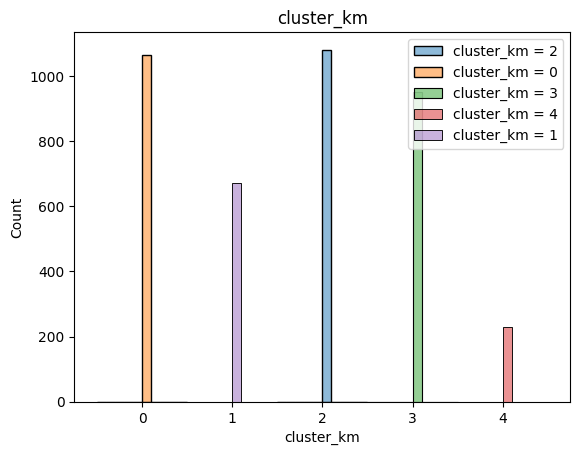

In [27]:
# Probar distintos números de clusters (de 2 a 5 grupos)
silhouette_scores = {}
for k in range(2, 6):
    km = KMeans(n_clusters = k)
    labels = km.fit_predict(df.drop(columns = ['Churn']))
    df['cluster_km'] = labels
    
    #Evaluar calidad del clustering
    print('Silhouette_score',k ,'Clusters:',round(silhouette_score(df, labels), 3))
    print()
    
    # cantidad por grupo
    print(df.groupby(['cluster_km']).count()["Churn"])
    print()
    
    #graficar
    graficar("cluster_km")

## 5. Conclusiones y recomendaciones

En el desarrollo del modelo y la segmentación de grupos, se decidió no incluir las columnas gender y Phone, ya que mostraron baja correlación con la variable objetivo; es decir, no están relacionadas con la probabilidad de que un cliente permanezca o se retire.

Al eliminar estas variables, los modelos presentaron un mejor desempeño. El mejor resultado se obtuvo con Regresión Logística, alcanzando:
- Exactitud (Accuracy): 0.94
- Precisión (Precision): 0.90
- Recall: 0.83

Además, la eliminación de estas columnas redujo el ruido en los datos, lo que permitió obtener clusters más definidos.
Si se buscara una segmentación más detallada, podría aumentarse el número de clusters, sacrificando ligeramente la calidad, sin que la métrica de desempeño se vea afectada de manera significativa.